# ROC Curve

Conda environment for this notebook: `conda env create`

Based on [HLS4ML tutorial plotting.py](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/plotting.py)


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotting

# standardize colors
from cycler import cycler 
colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]
plt.rcParams['axes.prop_cycle'] = cycler('color', colors)

# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

Just a simple diagram for explaining the ROC-curve with a perfect curve, an uninformative (basically random), and examples from the saved data in "testmodel"

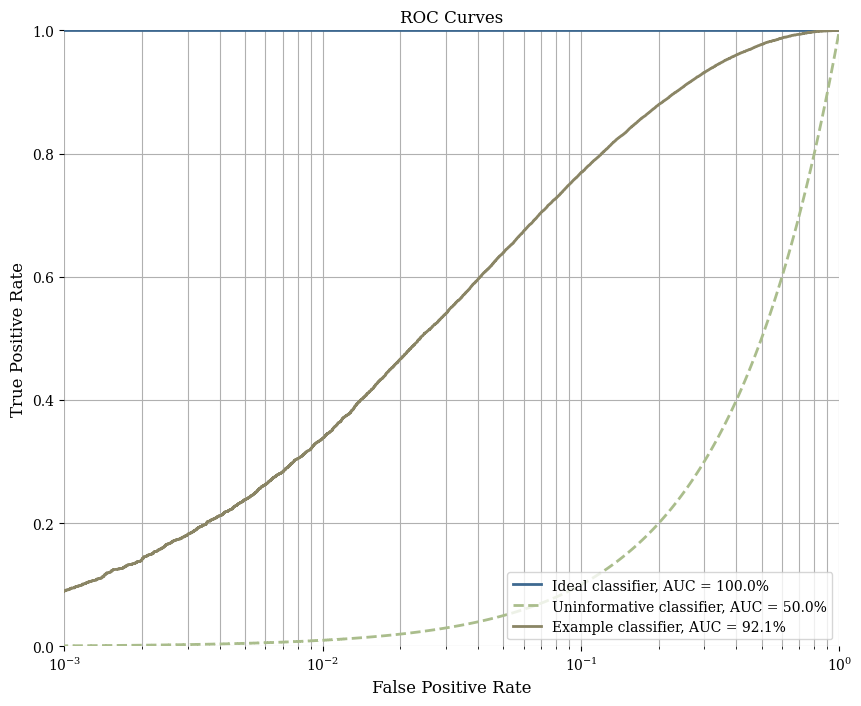

In [4]:
y_true = np.load("../_OldExports/testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

# Example classifier: good but not perfect separation
y_example = np.load("../_OldExports/testmodel/y_keras.npy")

# Uninformative classifier, "random"
y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

plt.figure(figsize=(10, 8))
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="-")
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--")
plotting.makeRoc(y_true, y_example, ["Example classifier"], linestyle="-")
plt.title("ROC Curves")
plt.show()

In [7]:
y_example

array([[4.5453802e-01, 3.7526885e-01, 3.4573641e-02, 4.3469880e-02,
        9.2149697e-02],
       [6.6780299e-02, 6.0085970e-01, 4.9611861e-03, 2.0727976e-01,
        1.2011903e-01],
       [1.7307891e-01, 6.4765006e-02, 7.6162130e-01, 1.1853758e-11,
        5.3489918e-04],
       ...,
       [2.2006836e-02, 8.1384309e-02, 3.9013460e-02, 7.1500337e-01,
        1.4259209e-01],
       [5.2382082e-02, 1.2592949e-01, 8.1920242e-01, 6.5532137e-12,
        2.4860704e-03],
       [1.0666945e-01, 9.0021916e-02, 8.1615500e-02, 4.8210490e-01,
        2.3958816e-01]], shape=(166000, 5), dtype=float32)

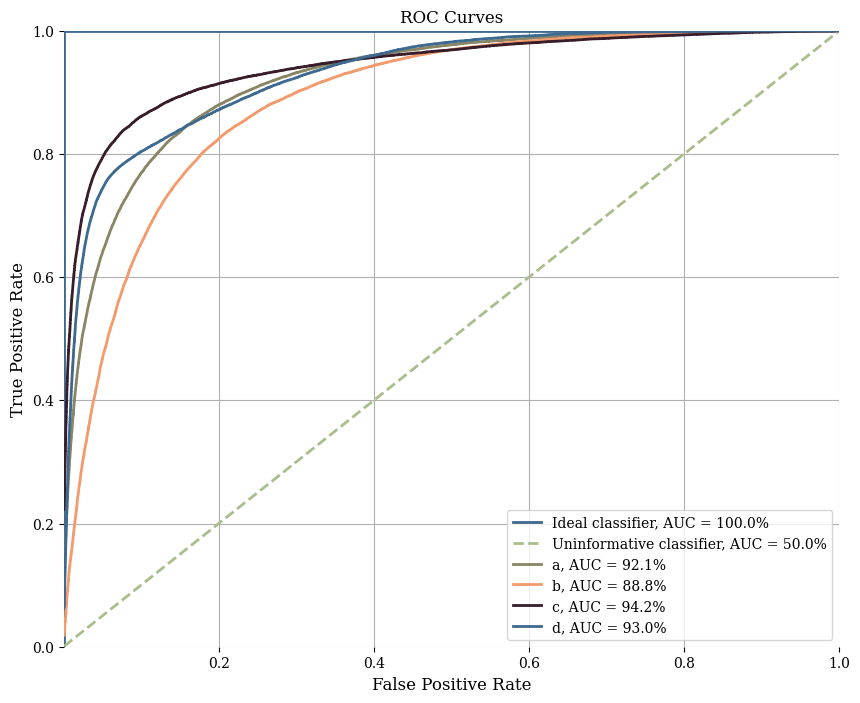

In [3]:
y_true = np.load("../testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

# Example classifier: good but not perfect separation
y_example = np.load("../testmodel/y_keras.npy")
example_classes = np.load("../testmodel/classes.npy", allow_pickle=True)

# Uninformative classifier, "random"
y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

plt.figure(figsize=(10, 8))
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="-", semilogx=False)
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", semilogx=False)
plotting.makeRoc(y_true, y_example, ["a","b","c","d"], linestyle="-", semilogx=False)
plt.title("ROC Curves")
plt.show()

Put side by side for insight into how to analyze

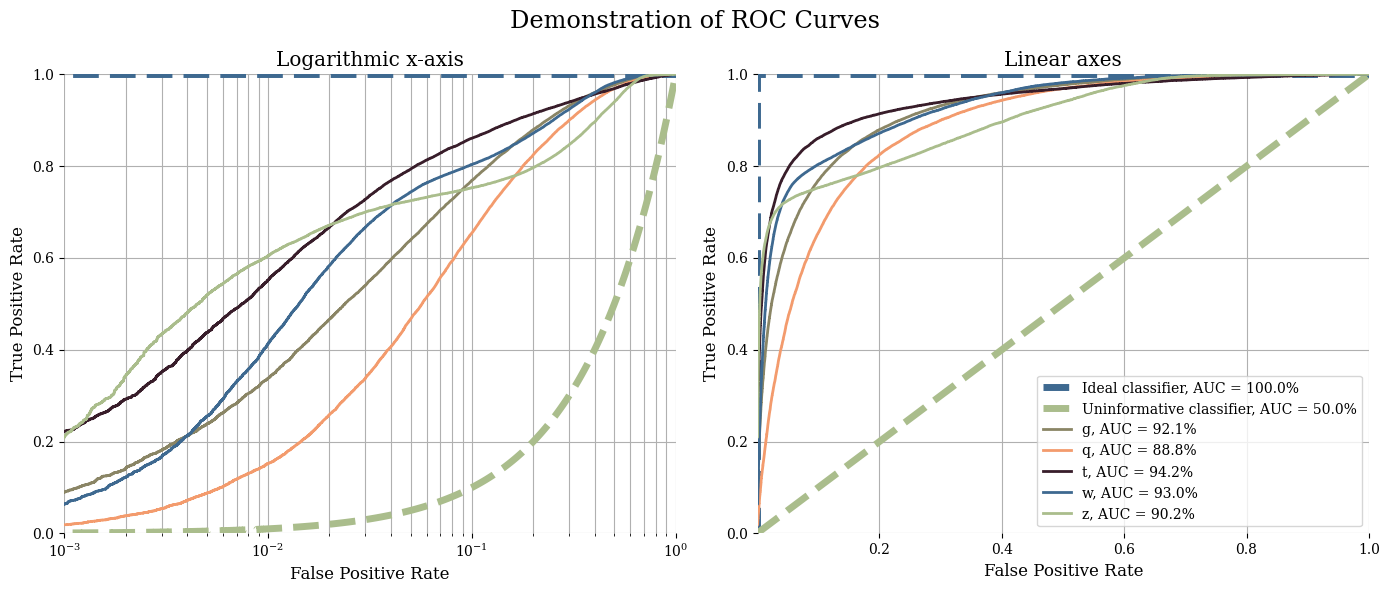

In [10]:
plotname = "Demonstration of ROC Curves"

y_true = np.load("../testmodel/y_test.npy")
n_samples = y_true.shape[0]

# Ideal classifier: perfect separation
y_ideal = y_true.copy()

y_example = np.load("../testmodel/y_keras.npy")
example_classes = np.load("../testmodel/classes.npy", allow_pickle=True)
#example_classes = ["Example classifier 1", "Example classifier 2", "Example classifier 3", "Example classifier 4",
#                   "Example classifier 5"] # Does not use the true names as its only an abstract showcase

y_true_uninformative = np.tile([0, 1], n_samples // 2)
uninformative_scores = np.linspace(0, 1, n_samples)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Logarithmic
plt.sca(axs[0])
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="--", linewidth=5, legend=False)
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", linewidth=5, legend=False)
plotting.makeRoc(y_true, y_example, example_classes, linestyle="-", semilogx=False, legend=False)
axs[0].set_title("Logarithmic x-axis", size='x-large')

# Linear
plt.sca(axs[1])
plotting.makeRoc(y_true, y_ideal, ["Ideal classifier"], linestyle="--", linewidth=5, semilogx=False, legends='default')
plotting.makeRoc(y_true_uninformative.reshape(-1, 1), uninformative_scores.reshape(-1, 1), ["Uninformative classifier"], linestyle="--", linewidth=5, semilogx=False, legends='default')
plotting.makeRoc(y_true, y_example, example_classes, linestyle="-", semilogx=False, legends='default')
axs[1].set_title("Linear axes",size='x-large')

plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
plt.tight_layout()
plt.show()

fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")